In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score


import warnings
warnings.filterwarnings('ignore')


In [2]:
Synthetic_Financial_datasets = pd.read_csv('/content/Synthetic_Financial_datasets_log.csv')

In [3]:
# Display the first few rows to understand the dataset structure
print("First few rows of the dataset:")
print(Synthetic_Financial_datasets.head())

First few rows of the dataset:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [4]:
# Show the general structure of the dataset (data types, number of rows, etc.)
print("\nDataset Information:")
print(Synthetic_Financial_datasets.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


In [5]:
# Check for missing values
print("\nMissing values in each column:")
print(Synthetic_Financial_datasets.isnull().sum())


Missing values in each column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [6]:
# Dropping rows with missing values
Synthetic_Financial_datasets.dropna(inplace=True)

In [7]:
# Verify that missing values are handled
print(Synthetic_Financial_datasets.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [8]:
# Check for duplicate rows
duplicates = Synthetic_Financial_datasets.duplicated()

# Display the number of duplicate rows
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 0


In [9]:
# Generate summary statistics for the dataset
summary_stats = Synthetic_Financial_datasets.describe()

# Display the summary statistics
print("Summary Statistics of the Dataset:")
print(summary_stats)

Summary Statistics of the Dataset:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25

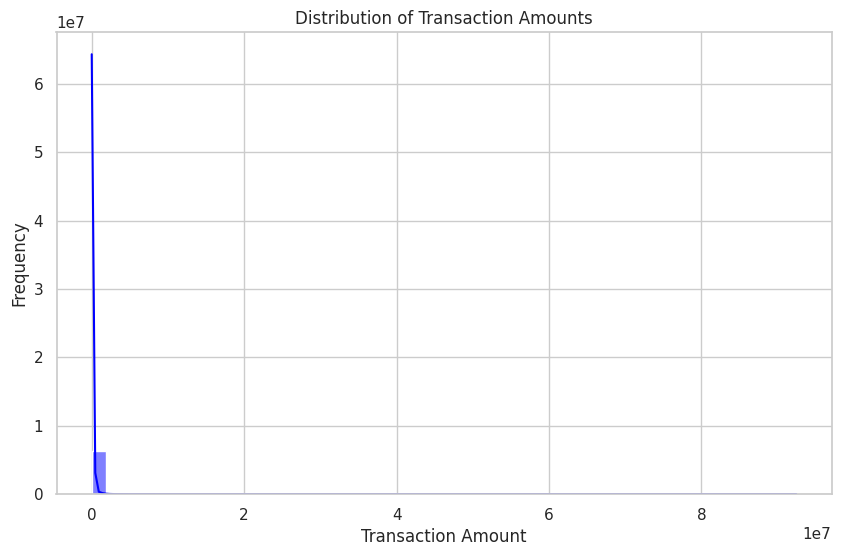

In [10]:
# Set up a seaborn style for plots
sns.set(style="whitegrid")

# Understand the Distribution of Transaction Amounts
plt.figure(figsize=(10, 6))
sns.histplot(Synthetic_Financial_datasets['amount'], kde=True, bins=50, color='blue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

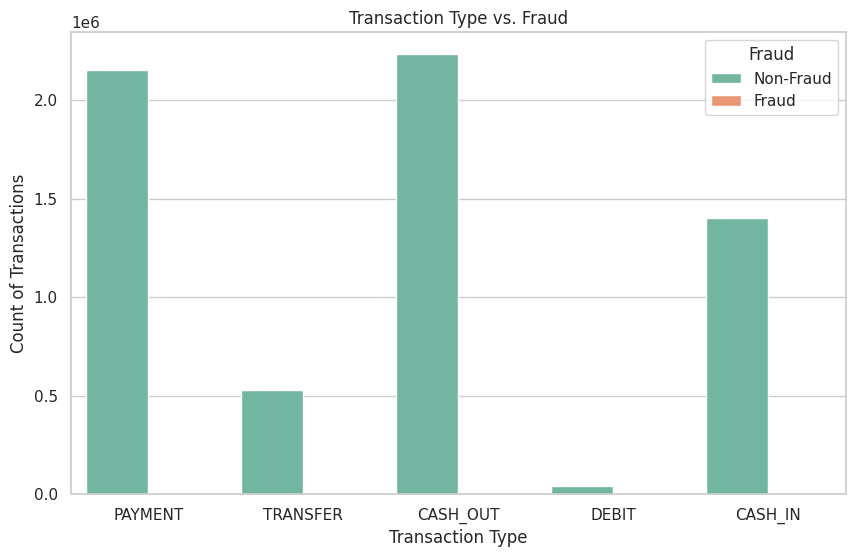

In [11]:
#  Investigate the Relationship between Transaction Type and Fraud
plt.figure(figsize=(10, 6))
sns.countplot(data=Synthetic_Financial_datasets, x='type', hue='isFraud', palette='Set2')
plt.title('Transaction Type vs. Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count of Transactions')
plt.legend(title='Fraud', labels=['Non-Fraud', 'Fraud'])
plt.show()

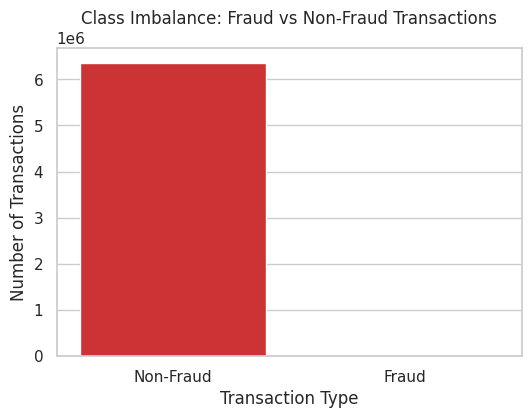

In [12]:
#  Check the Class Imbalance in Fraud vs. Non-Fraud
fraud_count = Synthetic_Financial_datasets['isFraud'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_count.index, y=fraud_count.values, palette='Set1')
plt.title('Class Imbalance: Fraud vs Non-Fraud Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
plt.show()

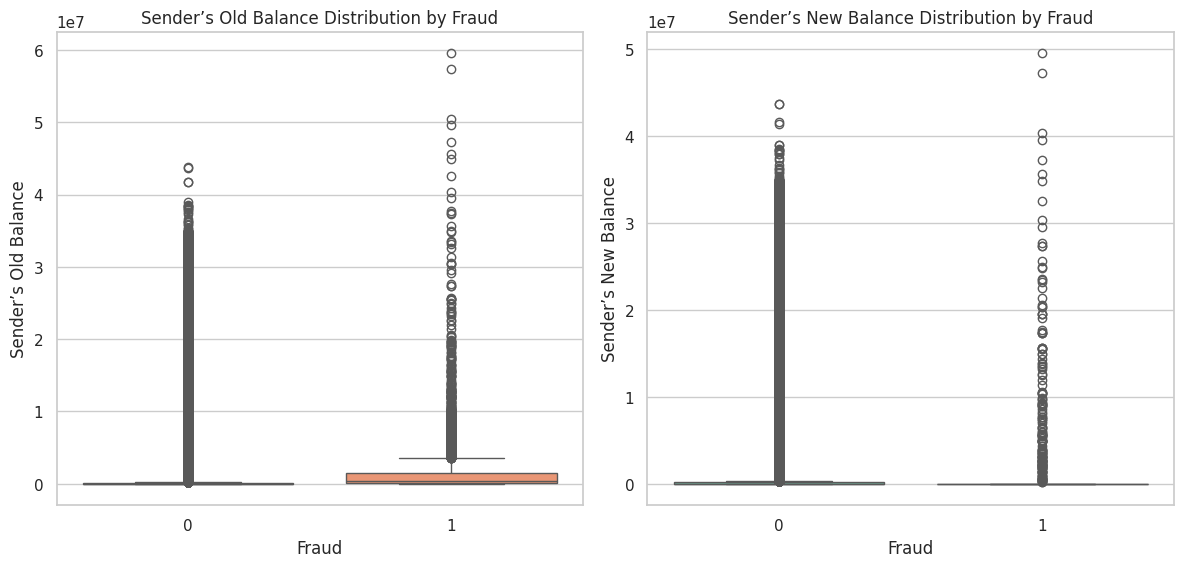

In [13]:
# Analyze the Distribution of Balances (Before and After Transactions)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=Synthetic_Financial_datasets, palette='Set2')
plt.title('Sender’s Old Balance Distribution by Fraud')
plt.xlabel('Fraud')
plt.ylabel('Sender’s Old Balance')

plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='newbalanceOrig', data=Synthetic_Financial_datasets, palette='Set2')
plt.title('Sender’s New Balance Distribution by Fraud')
plt.xlabel('Fraud')
plt.ylabel('Sender’s New Balance')

plt.tight_layout()
plt.show()

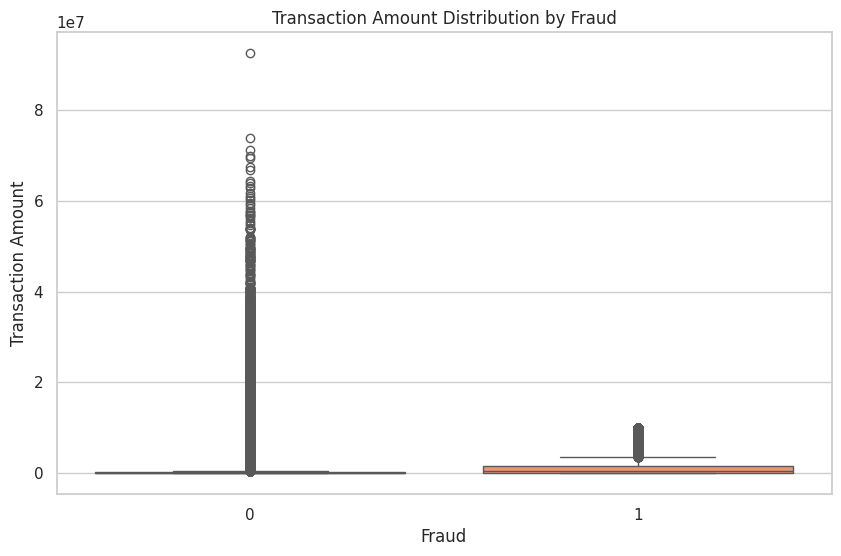

In [14]:
#  Investigate the Relationship Between Fraud and Transaction Amount
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=Synthetic_Financial_datasets, palette='Set2')
plt.title('Transaction Amount Distribution by Fraud')
plt.xlabel('Fraud')
plt.ylabel('Transaction Amount')
plt.show()

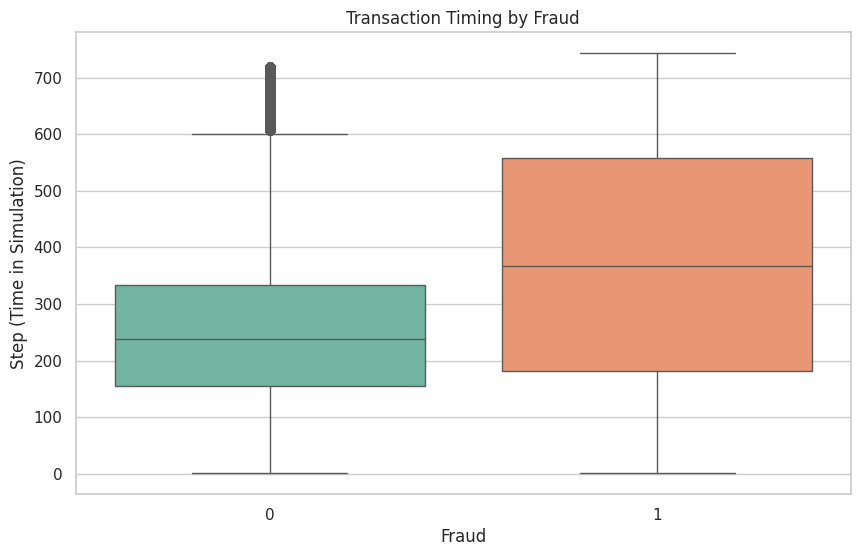

In [15]:
# Investigate the Relationship Between Fraud and Transaction Timing (Step)
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='step', data=Synthetic_Financial_datasets, palette='Set2')
plt.title('Transaction Timing by Fraud')
plt.xlabel('Fraud')
plt.ylabel('Step (Time in Simulation)')
plt.show()

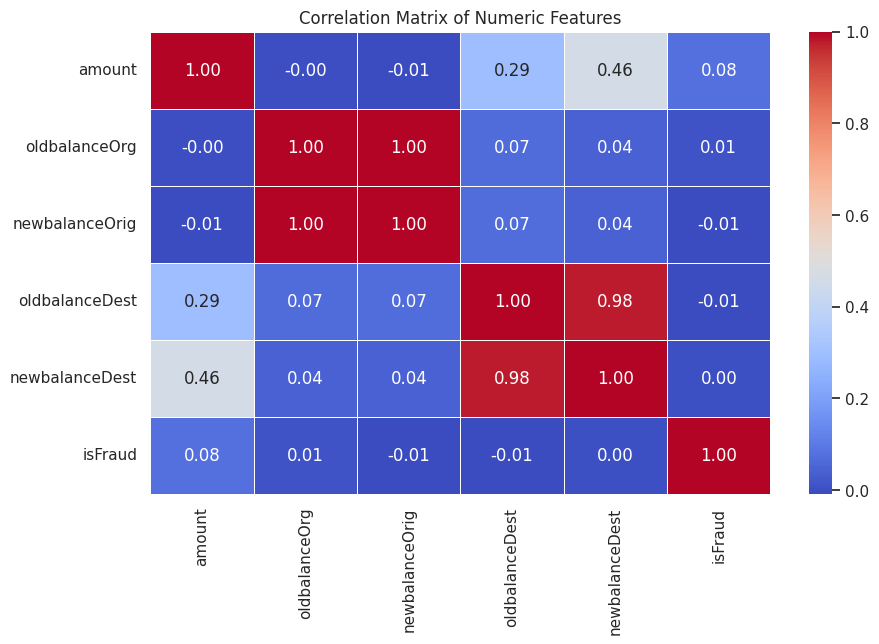

In [16]:
# Correlation Matrix to Explore Relationships Between Numeric Features
# Check the correlation of numerical features
corr = Synthetic_Financial_datasets[['amount', 'oldbalanceOrg', 'newbalanceOrig',
                                     'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

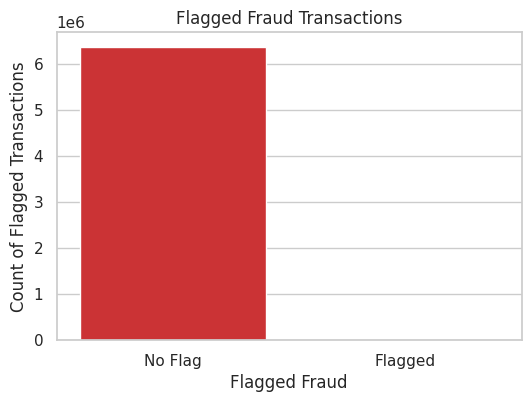

In [17]:
#  Understand the Frequency of Flagged Fraud Transactions
plt.figure(figsize=(6, 4))
sns.countplot(data=Synthetic_Financial_datasets, x='isFlaggedFraud', palette='Set1')
plt.title('Flagged Fraud Transactions')
plt.xlabel('Flagged Fraud')
plt.ylabel('Count of Flagged Transactions')
plt.xticks([0, 1], ['No Flag', 'Flagged'])
plt.show()

# **Encode Categorical Variables**

In [18]:
# Encode 'type' and 'nameOrig', 'nameDest' as labels
label_encoder = LabelEncoder()

# Encoding the 'type' column (transaction type)
Synthetic_Financial_datasets['type'] = label_encoder.fit_transform(Synthetic_Financial_datasets['type'])

# Encoding the 'nameOrig' and 'nameDest' columns (customer names)
Synthetic_Financial_datasets['nameOrig'] = label_encoder.fit_transform(Synthetic_Financial_datasets['nameOrig'])
Synthetic_Financial_datasets['nameDest'] = label_encoder.fit_transform(Synthetic_Financial_datasets['nameDest'])


# **Feature Scaling**

In [19]:
# Standardizing numerical features (scaling) to have zero mean and unit variance
scaler = StandardScaler()

# Identify numerical columns to scale, excluding the target variable 'isFraud'
numeric_columns = Synthetic_Financial_datasets.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'isFraud' in numeric_columns:
    numeric_columns.remove('isFraud')

# Scale the numerical features that are continuous, excluding the 'isFraud' target
Synthetic_Financial_datasets[numeric_columns] = scaler.fit_transform(Synthetic_Financial_datasets[numeric_columns])

# **Split the Data into Training and Test Sets**

In [20]:
# Separate the target variable ('isFraud') and the features
X = Synthetic_Financial_datasets.drop(columns=['isFraud'])
y = Synthetic_Financial_datasets['isFraud']

# Split the data into training and test sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
# Review the Prepared Data
print(f"Shape of the training data: {X_train.shape}")
print(f"Shape of the test data: {X_test.shape}")
print("First few rows of the training data (X_train):")
print(X_train.head())

Shape of the training data: (5090096, 10)
Shape of the test data: (1272524, 10)
First few rows of the training data (X_train):
             step      type    amount  nameOrig  oldbalanceOrg  \
6271196  2.638921 -1.269631  0.342006  0.693826       1.328035   
1888243 -0.557831 -1.269631  0.053981  1.437842      -0.207478   
5549957  0.973799  0.952399 -0.264788  1.468773      -0.287458   
2025342 -0.445418 -0.528954  0.575888  1.046440      -0.226320   
682342  -1.457138  1.693076  0.043398  1.298241      -0.288716   

         newbalanceOrig  nameDest  oldbalanceDest  newbalanceDest  \
6271196        1.436652 -0.609481       -0.174944       -0.300846   
1888243       -0.139539 -0.722490       -0.086687       -0.171855   
5549957       -0.292442  0.799824       -0.323814       -0.333411   
2025342       -0.292442 -0.399175       -0.296702       -0.164726   
682342        -0.292442 -0.543835        0.303248        0.302811   

         isFlaggedFraud  
6271196       -0.001586  
1888243  

# **Logistic Regression Model**

In [22]:
# Initialize the Logistic Regression model
logreg_model = LogisticRegression(random_state=42)

In [23]:
# Train the Logistic Regression model
logreg_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [24]:
# Make predictions on the test data
y_pred_logreg = logreg_model.predict(X_test)

# **Evaluate the Model**

In [25]:
# Evaluate the Logistic Regression model
print("Logistic Regression Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision, Recall, F1-Score, and Support:")
print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_logreg))

Logistic Regression Model Evaluation:
Accuracy: 0.9992031584473063
Precision, Recall, F1-Score, and Support:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.91      0.42      0.57      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.71      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.7083061873018471


# **Gradient Boosting Model**

# **XGBoost Model**

In [28]:
# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

In [29]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# **Evaluate the Model**

In [31]:
# Evaluate the XGBoost model
print("XGBoost Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision, Recall, F1-Score, and Support:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

XGBoost Model Evaluation:
Accuracy: 0.9994200502308798
Precision, Recall, F1-Score, and Support:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.81      0.71      0.76      1620

    accuracy                           1.00   1272524
   macro avg       0.91      0.86      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.8551410833995252


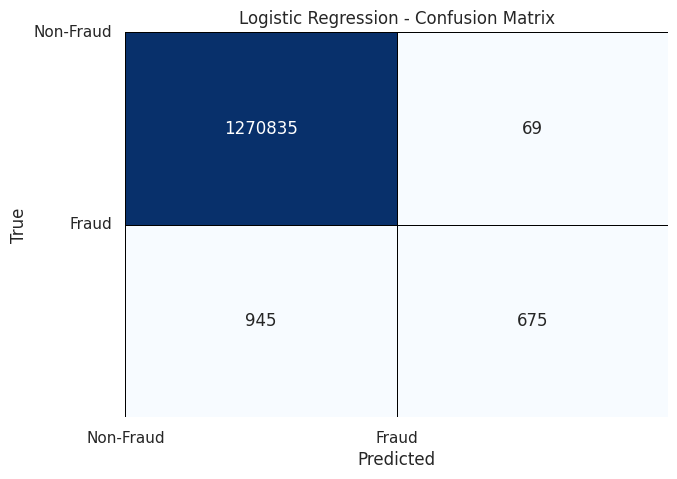

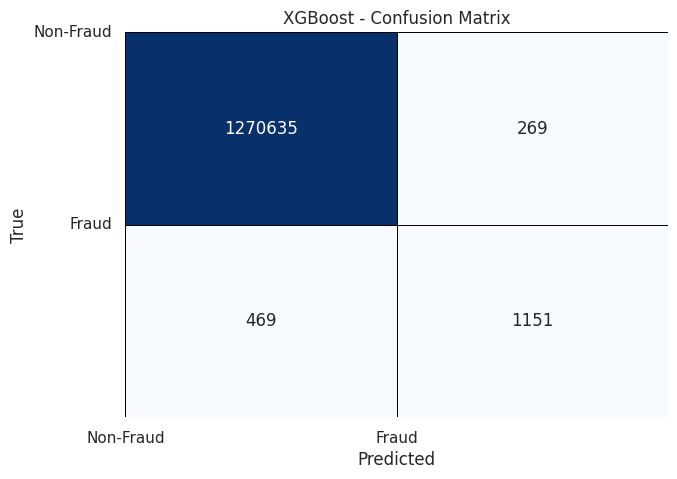

In [32]:
# Function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black', cbar=False)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
    plt.yticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
    plt.show()

#  Plot confusion matrix
plot_confusion_matrix(y_test, y_pred_logreg, 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')